# Clasificación de imágenes con Transfer Learning

En esta notebook vamos a construir un clasificador simple para distinguir entre **botellas y latas** a partir de imágenes.

El objetivo principal no es diseñar una red desde cero, sino entender cómo podemos **reutilizar redes neuronales convolucionales preentrenadas** (*transfer learning*) para resolver problemas reales con pocos datos.

En escenarios industriales o de laboratorio, rara vez contamos con datasets grandes, balanceados y perfectamente etiquetados. Por el contrario, es común trabajar con:

- Pocas imágenes disponibles
- Clases desbalanceadas
- Variaciones de iluminación, fondo y perspectiva
- Etiquetas imperfectas o ruidosas

En este contexto, entrenar una red profunda desde cero no suele ser la mejor estrategia.

En su lugar, vamos a aprovechar una red ya entrenada en millones de imágenes (como ImageNet), que ya aprendió a detectar patrones visuales generales como bordes, texturas y formas.

La idea es:

1. Utilizar una red convolucional preentrenada como extractor de características.
2. Congelar (o reutilizar) sus capas internas.
3. Entrenar una pequeña "cabeza" de clasificación adaptada a nuestro problema específico.

Esto nos permite construir modelos útiles incluso con datasets pequeños, y nos acerca a un flujo de trabajo típico en visión por computadora aplicada.

Más adelante veremos también qué ocurre cuando los datos no son suficientemente representativos del problema real, y cómo eso impacta directamente en el rendimiento del modelo.

# 1. Setup

Las imagenes que se han guardado en los directorios de entrenamiento son de distintos tamaños
Además deben ser pre-procesadas para generar un set que colabore con la etapa de entrenamiento


In [1]:
try:
    from google.colab import drive
    EN_COLAB = True
    !pip install supervision
    !pip install torchinfo
except:
    EN_COLAB = False


In [2]:
# ============================================================
# 1. SISTEMA / UTILIDADES GENERALES
# ============================================================
import os
from pathlib import Path
import zipfile
import time
import shutil

# ============================================================
# 2. VISUALIZACIÓN Y PROCESAMIENTO DE IMÁGENES
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv

# ============================================================
# 3. DEEP LEARNING (PYTORCH CORE)
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# ============================================================
# 4. MODELOS PREENTRENADOS (TRANSFER LEARNING)
# ============================================================
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# ============================================================
# 5. UTILIDADES DE INSPECCIÓN DEL MODELO
# ============================================================
from torchinfo import summary
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

Extrayendo dataset...


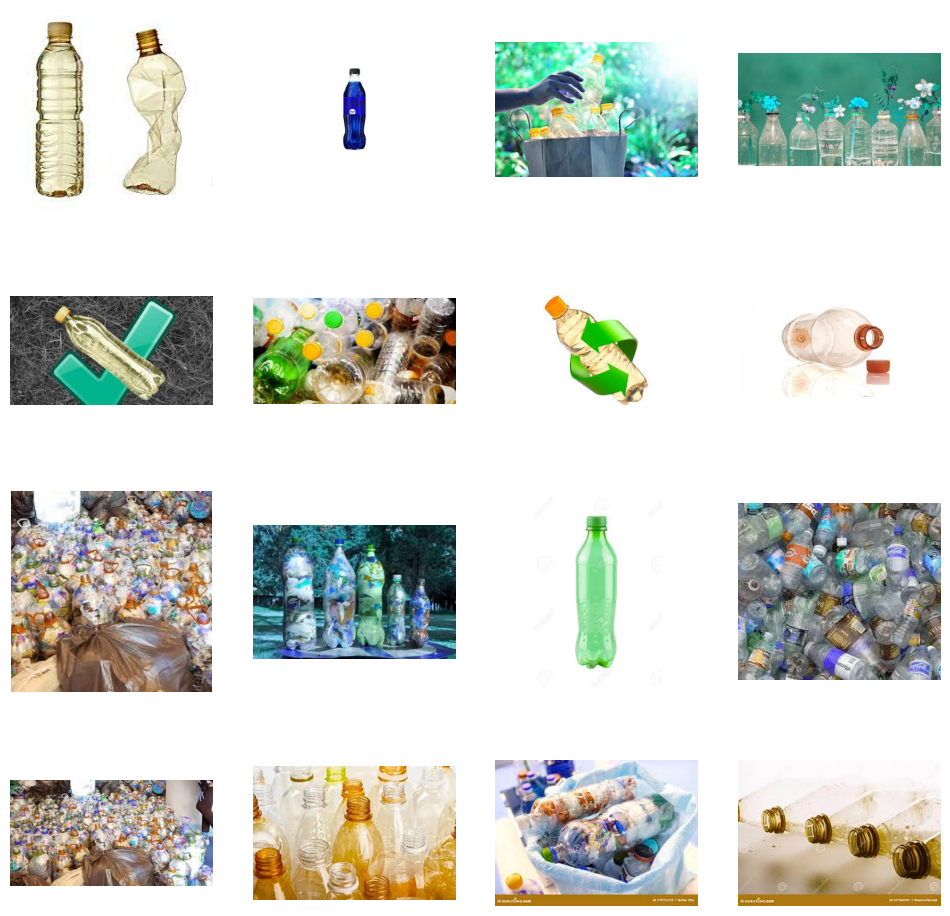

In [3]:
zip_dataset = f"dataset.zip"
file_model = f"model.pth"

if EN_COLAB:
    BASE = Path("/content")
    drive.mount('/content/drive')

    drive_dir = Path("/content/drive/MyDrive/Colab Notebooks/VISION/01_transfer_learning")
    shutil.copy(drive_dir / zip_dataset, BASE / zip_dataset)

    src = drive_dir / file_model
    if src.exists():
      shutil.copy(src, BASE / file_model)
else:
    BASE = Path(".").resolve()

# =========================
# Recupero DATASET
# =========================
datasets_dir = BASE / "dataset"
dataset_zip_path = BASE / zip_dataset
if not datasets_dir.exists():
    print("Extrayendo dataset...")
    with zipfile.ZipFile(dataset_zip_path, "r") as z:
        z.extractall(BASE)
else:
    print("Dataset ya disponible")


# Vemos algunas imagenes en las carpetas del dataset de botellas
imagenes_ejemplo = [
    cv2.cvtColor(
        cv2.imread(os.path.join('dataset/botellas', f)),
        cv2.COLOR_BGR2RGB
    )
    for f in os.listdir('dataset/botellas')[:16]
]
sv.plot_images_grid(images=imagenes_ejemplo,grid_size=(4,4))


{'botellas': 0, 'latas': 1}


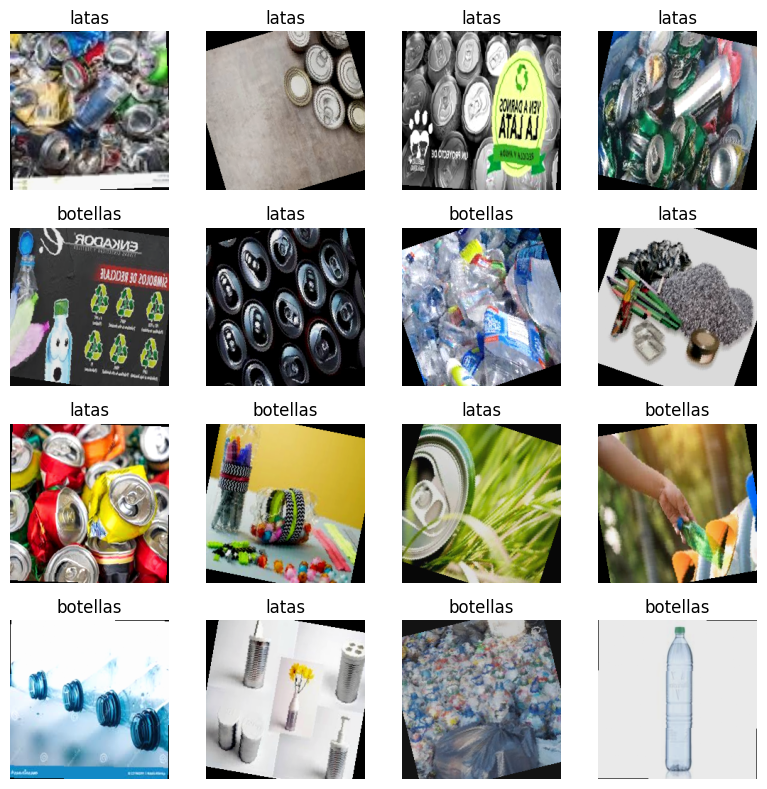

In [4]:
# La idea es cargar las imágenes en lotes (batches) y aplicar transformaciones de pre-procesamiento
# y aumentación de datos sobre la marcha, mientras se entrena el modelo
# Para esto, PyTorch nos ofrece la clase ImageFolder que nos permite cargar las imágenes desde
# los directorios y aplicar transformaciones a cada imagen de forma automática.
# Además, podemos usar DataLoader para cargar las imágenes en lotes y aplicar las transformaciones
# de forma eficiente.

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torch.utils.data import random_split

# Creamos el dataset a partir de las imágenes en los directorios
full_dataset = datasets.ImageFolder('dataset')
class_names = full_dataset.classes
print(full_dataset.class_to_idx)

# Hacemos la separación del dataset en entrenamiento y validación
n_train = int(0.75 * len(full_dataset))
n_val = len(full_dataset) - n_train
train_idx, val_idx = random_split(range(len(full_dataset)),[n_train, n_val])

# Creamos el dataloader para entrenamiento CON aumentación de datos plausibles
BATCH_SIZE = 32
train_transform = transforms.Compose([
      transforms.Resize((224,224)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(20),
      transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
      ),
      transforms.ToTensor(),
      transforms.Normalize((0.5,), (0.5,)), # image = (image - mean) / std
])
train_dataset = datasets.ImageFolder(
    'dataset',
    transform=train_transform
)
train_dataset = Subset(
    train_dataset,
    train_idx.indices
)
train_dataloader = DataLoader(
      train_dataset,
      batch_size=BATCH_SIZE,
      shuffle=True
)

# Creamos el dataloader para validación SIN aumentación de datos
val_transform = transforms.Compose([
      transforms.Resize((224,224)),
      transforms.ToTensor(),
      transforms.Normalize((0.5,), (0.5,)),
])
val_dataset = datasets.ImageFolder(
    'dataset',
    transform=val_transform,
)
val_dataset = Subset(
    val_dataset,
    val_idx.indices
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Muestro las imagenes que entrega el generador de imagenes de entrenamiento
imagenes, etiquetas = next(iter(train_dataloader))
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)

    img = imagenes[i].permute(1,2,0)*0.5+0.5 # desnormalizo la imagen para mostrarla

    plt.imshow(img)
    plt.title(train_dataset.dataset.classes[etiquetas[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [5]:
from collections import Counter
conteo = Counter()

# Contamos la cantidad de imágenes por clase en el conjunto de entrenamiento
for _, etiquetas in train_dataloader:
    conteo.update(etiquetas.tolist())

print("Conteo de etiquetas en el conjunto de entrenamiento:\n", conteo)

conteo.clear()
# Contamos la cantidad de imágenes por clase en el conjunto de validación
for _, etiquetas in val_dataloader:
    conteo.update(etiquetas.tolist())

print("Conteo de etiquetas en el conjunto de validación:\n", conteo)

Conteo de etiquetas en el conjunto de entrenamiento:
 Counter({1: 127, 0: 102})
Conteo de etiquetas en el conjunto de validación:
 Counter({1: 50, 0: 27})


# 2. Definimos la Red Neuronal

MobileNetV2 es una CNN diseñada para dispositivos con recursos limitados.
Utiliza convoluciones separables en profundidad (Depthwise Separable Convolutions),
reduciendo significativamente la cantidad de parámetros y operaciones respecto
de redes más grandes como VGG o ResNet.

La red fue entrenada originalmente sobre ImageNet (más de un millón de imágenes
distribuidas en 1000 clases), por lo que ya aprendió a detectar características
visuales generales como bordes, texturas, formas y patrones complejos.

En esta práctica utilizaremos MobileNetV2 como extractor de características:
congelamos sus pesos y reemplazamos únicamente la capa de clasificación final
para adaptarla a nuestro problema de botellas y latas.

Esta estrategia se conoce como Transfer Learning y permite obtener buenos
resultados incluso cuando disponemos de pocas imágenes para entrenamiento.

In [6]:
# Cargamos el modelo pre-entrenado
weights = MobileNet_V2_Weights.DEFAULT
modelo = mobilenet_v2(weights=weights)

# Congelamos los pesos del modelo pre-entrenado para que no se actualicen durante el entrenamiento
for param in modelo.parameters():
    param.requires_grad = False

# Reemplazamos la última capa del modelo para que se adapte a nuestro problema de clasificación binaria
modelo.classifier[1] = nn.Linear(modelo.last_channel,2)

summary(modelo,input_size=(BATCH_SIZE,3,224,224))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [32, 2]                   --
├─Sequential: 1-1                                  [32, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                   [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                            [32, 32, 112, 112]        (864)
│    │    └─BatchNorm2d: 3-2                       [32, 32, 112, 112]        (64)
│    │    └─ReLU6: 3-3                             [32, 32, 112, 112]        --
│    └─InvertedResidual: 2-2                       [32, 16, 112, 112]        --
│    │    └─Sequential: 3-4                        [32, 16, 112, 112]        (896)
│    └─InvertedResidual: 2-3                       [32, 24, 56, 56]          --
│    │    └─Sequential: 3-5                        [32, 24, 56, 56]          (5,136)
│    └─InvertedResidual: 2-4                       [32, 24, 56, 56]          --
│    │    └─Sequential

# 3. Entrenamiento!

Una vez definida la arquitectura de la red, comienza el proceso de entrenamiento.

El objetivo es ajustar los pesos de la última capa para minimizar una función de pérdida (*loss*) sobre el conjunto de entrenamiento. En este caso utilizamos:

- **Cross Entropy Loss** como función de costo para clasificación.
- **Adam** como algoritmo de optimización basado en gradiente descendente.

El entrenamiento se realiza de manera iterativa durante varias **épocas** (*epochs*). En cada época:

1. Se recorren todos los lotes (*batches*) del conjunto de entrenamiento.
2. Se realiza una inferencia para obtener las predicciones.
3. Se calcula la pérdida comparando predicciones y etiquetas reales.
4. Se calcula el gradiente mediante retropropagación (*backpropagation*).
5. Se actualizan los pesos utilizando el optimizador.

Al finalizar cada época, el modelo se evalúa sobre un conjunto de validación independiente. Esto permite monitorear la capacidad de generalización y detectar posibles fenómenos de sobreajuste (*overfitting*).

Durante el entrenamiento se registran:

- Pérdida de entrenamiento (*training loss*).
- Pérdida de validación (*validation loss*).
- Exactitud (*accuracy*) de entrenamiento.
- Exactitud (*accuracy*) de validación.

Además, se guarda automáticamente el modelo que obtiene la menor pérdida sobre el conjunto de validación. De esta forma conservamos la mejor versión encontrada durante el proceso de optimización.

Finalmente, se grafican las curvas de pérdida y exactitud para analizar la evolución del aprendizaje.

Notar que los pesos no se reinician en esta celda, por lo que al ejecutarla repetidas veces lo hace a partir del punto al que había llegado.

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:21<00:00,  2.68s/it]


Nuevo mejor modelo guardado
Epoch 1/50 loss=0.6463 acc=0.576 val_loss=0.5510 val_acc=0.753


100%|██████████| 8/8 [00:19<00:00,  2.39s/it]


Nuevo mejor modelo guardado
Epoch 2/50 loss=0.5334 acc=0.834 val_loss=0.4619 val_acc=0.896


...

Epoch 48/50 loss=0.1092 acc=0.974 val_loss=0.2064 val_acc=0.896


100%|██████████| 8/8 [00:17<00:00,  2.19s/it]


Epoch 49/50 loss=0.1218 acc=0.978 val_loss=0.2034 val_acc=0.922


100%|██████████| 8/8 [00:17<00:00,  2.13s/it]


Epoch 50/50 loss=0.1284 acc=0.961 val_loss=0.2081 val_acc=0.922


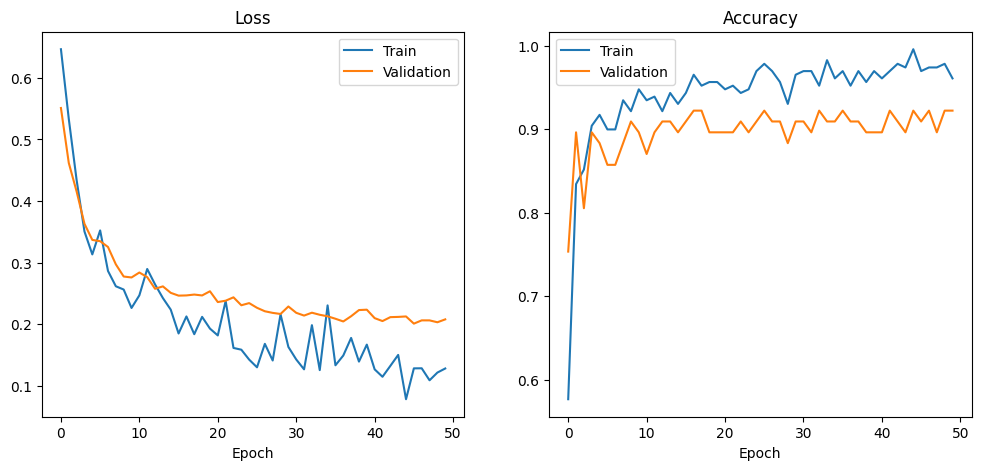

In [7]:
# Hiperparámetros
num_epochs = 50
learning_rate = 1e-3

# Historial de pérdidas y accuracies para graficar luego
hist_train_loss = []
hist_val_loss = []
hist_train_acc = []
hist_val_acc = []

# Configuro el Optimizador
optimizer = optim.Adam(modelo.classifier[1].parameters(),lr=learning_rate)

# Defino el criterio de pérdida
criterion = nn.CrossEntropyLoss()

# Iteramos sobre las épocas
best_val_loss = float('inf')
for epoch in range(num_epochs):
    # red en modo training
    modelo.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    # Iteramos sobre los batches del dataloader de entrenamiento
    for imagenes, etiquetas in tqdm(train_dataloader):
        # Reinicio los gradientes del optimizador porque actualizamos 1 vez por batch
        optimizer.zero_grad()
        # Realizo la inferencia del batch entero
        salida = modelo(imagenes)
        # Calculo la pérdida del batch entero
        loss = criterion(salida, etiquetas)
        # Realizo el backward pass para calcular los gradientes de la pérdida con respecto
        # a los pesos de la última capa del modelo
        loss.backward()
        # Actualizo los pesos de la última capa del modelo usando el optimizador
        optimizer.step()

        # Acumulo la pérdida del batch para luego promediarla y mostrarla
        train_loss += loss.item()
        # Calculo la cantidad de aciertos del batch para luego promediarla y mostrarla
        pred = salida.argmax(dim=1)
        train_correct += (pred == etiquetas).sum().item()
        train_total += etiquetas.size(0)

    # Actualizo el valor de la pérdida promediando por la cantidad de batches
    train_loss /= len(train_dataloader)
    # Actualizo el valor de la accuracy promediando por la cantidad total de imágenes
    train_acc = train_correct / train_total

    # Evaluamos el modelo en el conjunto de validación
    modelo.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    # Evaluamos el modelo en el conjunto de validación sin calcular gradientes para ahorrar memoria
    # y acelerar la inferencia
    with torch.no_grad():
        for imagenes, etiquetas in val_dataloader:
            # Realizo la inferencia del batch de validación
            salida = modelo(imagenes)
            # Calculo la pérdida del batch de validación y la acumulo para luego promediarla y mostrarla
            loss = criterion(salida, etiquetas)
            val_loss += loss.item()
            # Calculo la cantidad de aciertos del batch de validación para luego promediarla y mostrarla
            pred = salida.argmax(dim=1)
            val_correct += (pred == etiquetas).sum().item()
            val_total += etiquetas.size(0)

    # Actualizo el valor de la pérdida promediando por la cantidad de batches
    val_loss /= len(val_dataloader)
    # Actualizo el valor de la accuracy promediando por la cantidad total de imágenes
    val_acc = val_correct / val_total

    # Si la pérdida de validación es la mejor que hemos obtenido hasta ahora, guardamos el modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            modelo.state_dict(),
            file_model
        )
        print("Nuevo mejor modelo guardado")

    # Acumulo los valores de pérdida y accuracy para graficar luego
    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_train_acc.append(train_acc)
    hist_val_acc.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"loss={train_loss:.4f} "
        f"acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.3f}"
    )

# Graficamos la evolución de la pérdida y la accuracy durante el entrenamiento
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_train_loss,label='Train')
plt.plot(hist_val_loss,label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_train_acc,label='Train')
plt.plot(hist_val_acc,label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()


## 4. Evaluamos el mejor modelo

In [8]:
# Recupero el mejor modelo obtenido durante el entrenamiento
modelo = mobilenet_v2(weights=None)

# Congelamos los pesos del modelo pre-entrenado para que no se actualicen durante el entrenamiento
for param in modelo.parameters():
    param.requires_grad = False

# Reemplazamos la última capa del modelo para que se adapte a nuestro problema de clasificación binaria
modelo.classifier[1] = nn.Linear(modelo.last_channel,2)
# Cargo los pesos del mejor modelo guardado durante el entrenamiento
modelo.load_state_dict(torch.load(file_model))
# Pongo el modelo en modo evaluación para que no se actualicen los pesos durante la inferencia
modelo.eval()

print("Modelo cargado")

Modelo cargado


Tiempo total: 4.603 s
Tiempo por imagen: 59.78 ms
FPS: 16.7
              precision    recall  f1-score   support

    botellas       0.86      0.89      0.87        27
       latas       0.94      0.92      0.93        50

    accuracy                           0.91        77
   macro avg       0.90      0.90      0.90        77
weighted avg       0.91      0.91      0.91        77



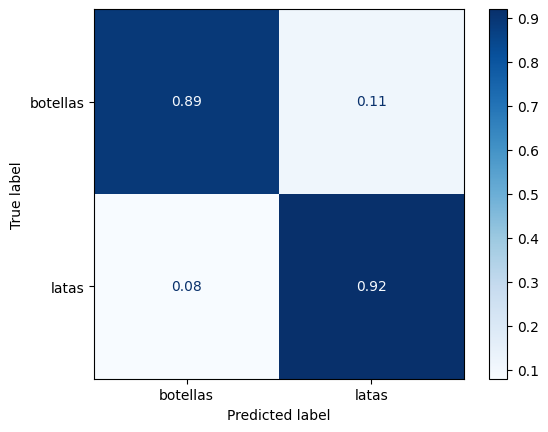

In [9]:
# Evaluamos el modelo en el conjunto de validación para obtener las predicciones y las etiquetas verdaderas
y_true = []
y_pred = []

num_imagenes = 0
t_ini = time.perf_counter()
with torch.no_grad():
    for imagenes, etiquetas in val_dataloader:
        # Realizo la inferencia
        salida = modelo(imagenes)
        # Tomo la clase con mayor probabilidad como predicción
        pred = salida.argmax(dim=1)
        # Acumulo las etiquetas verdaderas y las predicciones para luego calcular el reporte de clasificación y la matriz de confusión
        y_true.extend(etiquetas.numpy())
        y_pred.extend(pred.numpy())
        num_imagenes += etiquetas.size(0)

t_fin = time.perf_counter()
tiempo_total = t_fin - t_ini
tiempo_por_imagen = tiempo_total / num_imagenes

print(f"Tiempo total: {tiempo_total:.3f} s")
print(f"Tiempo por imagen: {1000*tiempo_por_imagen:.2f} ms")
print(f"FPS: {1/tiempo_por_imagen:.1f}")

print(classification_report(y_true,y_pred,target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,display_labels=class_names,normalize='true',cmap='Blues')
plt.show()

## 5. Jugamos a clasificar imágenes de internet

Clase predicha: 0 (botellas)
Probabilidad: 0.9335409998893738


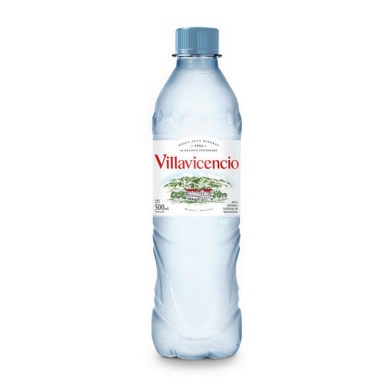

In [15]:
from PIL import Image
import requests
from io import BytesIO


# Juego un poco a identificar imagenes de internet
# estas URLs las obtuve con Google

url = 'https://statics.dinoonline.com.ar/imagenes/full_600x600_ma/3040004_f.jpg' #debe ser 0
#url = 'https://c8.alamy.com/compes/2f76fwj/latas-de-soda-de-aluminio-trituradas-para-reciclaje-ee-uu-2f76fwj.jpg'
#url ='https://www.shutterstock.com/image-vector/broken-aluminum-red-drink-can-260nw-1775214425.jpg'
#url ='https://mercoplast.com.py/img/productos/tapa-corta-para-botella-con-gas-2.jpg'
#url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR3nKa5Rx7Qhgqiphq9ylMkAqAcqadWtxhd-LbHVt6o4w&s=10'

respuesta = requests.get(url)
img_pil = Image.open(BytesIO(respuesta.content)).convert("RGB")
plt.imshow(img_pil)
plt.axis('off')

img_tensor = val_transform(img_pil)

with torch.no_grad():
    salida = modelo(img_tensor.unsqueeze(0))
    prob = torch.softmax(salida, dim=1)
    prediccion = salida.argmax(dim=1).item()
    print(f"Clase predicha: {prediccion} ({class_names[prediccion]})\nProbabilidad: {prob.numpy()[0,prediccion]}")

